# **Day 79: Domain Shift and Domain Adaptation**
*Module 12 - Trustworthy ML and MLOps*

A model trained in one place, season, sensor or hospital is used somewhere else, and accuracy drops. In remote sensing this is **the** central practical problem: crop maps trained in Punjab applied to West Bengal, a model trained on 2022 imagery applied to 2024, Landsat-trained models applied to Sentinel-2. **Domain adaptation** methods reduce the damage, especially when the new domain has **no or few labels**.

> Domain shift means the test data differs from the training data (another region, season or sensor), so accuracy drops. Domain adaptation techniques help a model transfer to the new conditions.
>
> *Example:* A crop model trained on 2023 data may fail in 2024 if the monsoon arrived late and every crop was sown three weeks later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
torch.manual_seed(79); rng = np.random.default_rng(79)

## **1. Types of Shift**

| Shift | What changes | RS example |
|---|---|---|
| **Covariate shift** | $p(\mathbf x)$ changes, $p(y\mid\mathbf x)$ same | target region has more irrigated (greener) fields |
| **Label / prior shift** | $p(y)$ changes, $p(\mathbf x\mid y)$ same | rice is 70% of fields in the target district vs 30% in training |
| **Concept shift** | $p(y\mid\mathbf x)$ changes | different sowing calendar: the same NDVI profile means a different crop; different sensor calibration |

## **2. A Two-District Crop Mapping Scenario**
Source district (labelled): 4 crops with 12-date NDVI profiles. Target district (unlabelled): crops sown **~3 weeks later**, different atmospheric conditions (brightness offset), and different crop proportions.

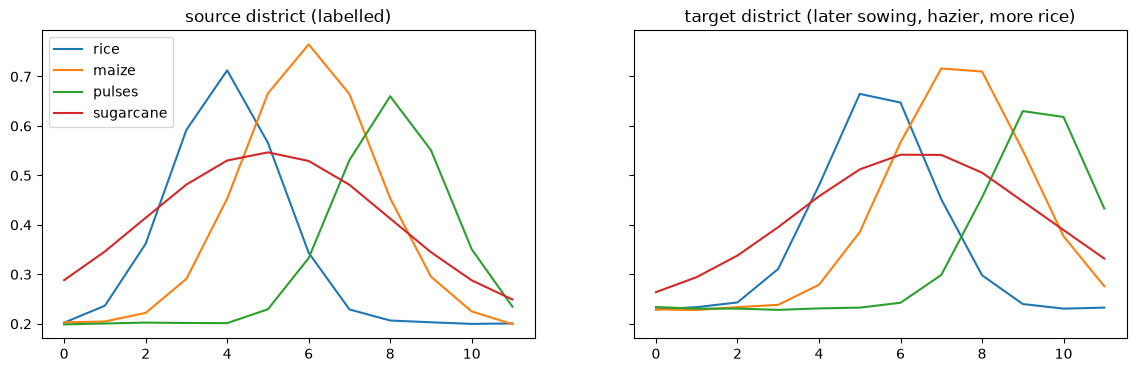

source CV accuracy 0.989 | accuracy when applied to target 0.529


In [2]:
T = 12; t = np.arange(T)
def profiles(n_per, shift_days=0, offset=0.0, gain=1.0, props=None, seed=0):
    r = np.random.default_rng(seed); X, y = [], []
    peaks = [4.0, 6.0, 8.0, 5.0]; widths = [1.2, 1.5, 1.2, 3.0]; heights = [0.55, 0.6, 0.5, 0.35]
    counts = (np.array(props) * n_per * 4).astype(int) if props is not None else [n_per] * 4
    for k, n in enumerate(counts):
        c = peaks[k] + shift_days / 15 + r.normal(0, 0.5, (n, 1))
        nd = 0.2 + heights[k] * np.exp(-0.5 * ((t - c) / widths[k]) ** 2) * r.uniform(0.8, 1.2, (n, 1))
        X.append(gain * nd + offset + r.normal(0, 0.03, (n, T))); y += [k] * n
    return np.vstack(X), np.array(y)

Xs, ys = profiles(300, seed=1)
Xt, yt = profiles(300, shift_days=22, offset=0.05, gain=0.9, props=[0.55, 0.15, 0.15, 0.15], seed=2)   # yt hidden in practice
crops = ["rice", "maize", "pulses", "sugarcane"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for k in range(4):
    axes[0].plot(Xs[ys == k].mean(0), label=crops[k]); axes[1].plot(Xt[yt == k].mean(0), label=crops[k])
axes[0].set_title("source district (labelled)"); axes[1].set_title("target district (later sowing, hazier, more rice)"); axes[0].legend(); plt.show()

src_model = RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(Xs, ys)
print(f"source CV accuracy {cross_val_score(RandomForestClassifier(300, random_state=0, n_jobs=-1), Xs, ys, cv=5).mean():.3f} | "
      f"accuracy when applied to target {src_model.score(Xt, yt):.3f}")

## **3. Detecting Shift With a Domain Classifier**
Train a classifier to tell source samples from target samples. If it cannot (AUC ~ 0.5), the domains look alike; a high AUC means shift, and its probabilities give **importance weights**.

In [3]:
Xd = np.vstack([Xs, Xt]); d = np.r_[np.zeros(len(Xs)), np.ones(len(Xt))]
dom_auc = cross_val_score(HistGradientBoostingClassifier(random_state=0), Xd, d, cv=5, scoring="roc_auc").mean()
print(f"domain classifier ROC-AUC = {dom_auc:.3f}  (0.5 = indistinguishable)")
from scipy.stats import ks_2samp
print("per-date KS-test p-values (source vs target NDVI):", np.round([ks_2samp(Xs[:, j], Xt[:, j]).pvalue for j in range(T)], 4))

domain classifier ROC-AUC = 0.972  (0.5 = indistinguishable)
per-date KS-test p-values (source vs target NDVI): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## **4. Covariate Shift: Importance Weighting**
If only $p(\mathbf x)$ changed, re-weight source samples by $w(\mathbf x) = \frac{p_t(\mathbf x)}{p_s(\mathbf x)} = \frac{P(d=1\mid\mathbf x)}{P(d=0\mid\mathbf x)}\frac{n_s}{n_t}$ from the domain classifier. Here it helps little, because the main problem is **concept shift** (later sowing changes what a profile means) and weights explode where supports do not overlap.

In [4]:
dom = LogisticRegression(max_iter=3000, C=0.1).fit(Xd, d); pt = dom.predict_proba(Xs)[:, 1]
w = np.clip(pt / (1 - pt) * len(Xs) / len(Xt), 0, 20)
m_w = RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(Xs, ys, sample_weight=w)
print(f"importance-weighted model on target: {m_w.score(Xt, yt):.3f} | effective sample size {w.sum() ** 2 / (w ** 2).sum():.0f} of {len(w)}")

importance-weighted model on target: 0.537 | effective sample size 939 of 1200


## **5. Domain-Invariant Features and Feature Alignment**
**Physics first**: features robust to the shift often beat any algorithm. Here, per-sample normalisation removes the haze offset/gain, and **phenology-relative** features (shape of the curve aligned to its own peak) remove the sowing delay.

In [5]:
def standardise_rows(X): return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)
def peak_aligned(X, w_=5):
    Z = standardise_rows(X); out = []
    for z in Z:
        p = int(np.argmax(np.convolve(z, np.ones(3) / 3, "same"))); idx = np.clip(np.arange(p - w_, p + w_ + 1), 0, T - 1); out.append(z[idx])
    return np.array(out)
for name, fn in [("raw NDVI", lambda X: X), ("per-sample standardised", standardise_rows), ("peak-aligned + standardised", peak_aligned)]:
    m = RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(fn(Xs), ys)
    print(f"{name:<30} source CV {cross_val_score(RandomForestClassifier(300, random_state=0, n_jobs=-1), fn(Xs), ys, cv=5).mean():.3f} | target {m.score(fn(Xt), yt):.3f}")

raw NDVI                       source CV 0.989 | target 0.529


per-sample standardised        source CV 0.985 | target 0.496


peak-aligned + standardised    source CV 0.903 | target 0.823


### CORAL: align second-order statistics
CORAL (Sun et al., 2016) whitens the source features and re-colours them with the target covariance, so that both domains have the same mean and covariance. Unsupervised: uses no target labels.

In [6]:
def coral(Xs_, Xt_, eps=1.0):
    from scipy.linalg import sqrtm
    Cs, Ct = np.cov(Xs_, rowvar=False) + eps * np.eye(Xs_.shape[1]) * 1e-3, np.cov(Xt_, rowvar=False) + eps * np.eye(Xs_.shape[1]) * 1e-3
    A = np.real(np.linalg.inv(sqrtm(Cs)) @ sqrtm(Ct))
    return (Xs_ - Xs_.mean(0)) @ A + Xt_.mean(0)
Xs_c = coral(Xs, Xt)
print(f"CORAL-aligned source -> target accuracy: {RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(Xs_c, ys).score(Xt, yt):.3f}")

CORAL-aligned source -> target accuracy: 0.547


### Adversarial domain adaptation (DANN)
Ganin et al. (2016): a feature extractor feeds both a **label classifier** (trained on source labels) and a **domain classifier**. A **gradient reversal layer** makes the extractor learn features that **fool** the domain classifier: features that are discriminative for the task but domain-invariant.

In [7]:
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam): ctx.lam = lam; return x.view_as(x)
    @staticmethod
    def backward(ctx, g): return -ctx.lam * g, None

class DANN(nn.Module):
    def __init__(self, d_in=T, h=64, n_classes=4):
        super().__init__()
        self.feat = nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU())
        self.cls = nn.Linear(h, n_classes); self.dom = nn.Sequential(nn.Linear(h, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x, lam=0.0):
        f = self.feat(x); return self.cls(f), self.dom(GradReverse.apply(f, lam))

def train_dann(lam_max=1.0, epochs=300, seed=0):
    torch.manual_seed(seed); m = DANN(); opt = torch.optim.Adam(m.parameters(), 1e-3)
    S, Y, Tt = torch.tensor(standardise_rows(Xs), dtype=torch.float32), torch.tensor(ys), torch.tensor(standardise_rows(Xt), dtype=torch.float32)
    for ep in range(epochs):
        lam = lam_max * (2 / (1 + np.exp(-10 * ep / epochs)) - 1)                    # ramp up the adversarial strength
        ys_hat, ds = m(S, lam); _, dt = m(Tt, lam)
        loss = F.cross_entropy(ys_hat, Y) + F.binary_cross_entropy_with_logits(torch.cat([ds, dt]).squeeze(1), torch.cat([torch.zeros(len(S)), torch.ones(len(Tt))]))
        opt.zero_grad(); loss.backward(); opt.step()
    m.eval()
    with torch.no_grad(): return (m(Tt)[0].argmax(1).numpy() == yt).mean()
print(f"MLP on standardised profiles, no adaptation (lambda = 0): target accuracy {train_dann(lam_max=0.0):.3f}")
print(f"DANN (gradient reversal, lambda -> 1)              : target accuracy {train_dann(lam_max=1.0):.3f}")

MLP on standardised profiles, no adaptation (lambda = 0): target accuracy 0.444


DANN (gradient reversal, lambda -> 1)              : target accuracy 0.512


## **6. Label Shift: Re-estimating Class Proportions**
If $p(\mathbf x\mid y)$ is unchanged but $p(y)$ differs, the classifier's priors are wrong. The **EM algorithm** of Saerens et al. (2002) re-estimates target class proportions from unlabelled target predictions and corrects the probabilities (Day 21's prior correction, with the target prior estimated).

In [8]:
def em_label_shift(P_src_test, prior_src, iters=100):
    prior_t = prior_src.copy()
    for _ in range(iters):
        P = P_src_test * (prior_t / prior_src); P /= P.sum(1, keepdims=True); prior_t = P.mean(0)
    return prior_t, P
X_ls, y_ls = profiles(300, props=[0.7, 0.1, 0.1, 0.1], seed=5)                          # pure label shift: same profiles, more rice
m_ls = LogisticRegression(max_iter=5000).fit(standardise_rows(Xs), ys); P0 = m_ls.predict_proba(standardise_rows(X_ls))
prior_hat, P_corr = em_label_shift(P0, np.bincount(ys) / len(ys))
print("true target proportions:", np.round(np.bincount(y_ls) / len(y_ls), 3), "| estimated:", prior_hat.round(3))
print(f"accuracy before correction {np.mean(P0.argmax(1) == y_ls):.3f} | after {np.mean(P_corr.argmax(1) == y_ls):.3f}")

true target proportions: [0.7 0.1 0.1 0.1] | estimated: [0.704 0.099 0.102 0.095]
accuracy before correction 0.978 | after 0.980


## **7. A Few Target Labels Go a Long Way**
Labelling even 10 fields per crop in the target district (fine-tuning or simply adding them to training) often beats sophisticated unsupervised adaptation. Combine: domain-robust features + a small, well-designed target sample (active learning, Day 57).

In [9]:
for n_lab in [0, 5, 10, 25, 50]:
    accs = []
    for rep in range(5):
        r_ = np.random.default_rng(rep); idx = np.concatenate([r_.choice(np.flatnonzero(yt == k), n_lab, replace=False) for k in range(4)]) if n_lab else np.array([], int)
        rest = np.setdiff1d(np.arange(len(yt)), idx)
        Xtr_ = np.vstack([peak_aligned(Xs), peak_aligned(Xt[idx])]) if n_lab else peak_aligned(Xs); ytr_ = np.r_[ys, yt[idx]]
        accs.append(RandomForestClassifier(300, random_state=rep, n_jobs=-1).fit(Xtr_, ytr_).score(peak_aligned(Xt[rest]), yt[rest]))
    print(f"{n_lab:>2} target labels per crop: target accuracy {np.mean(accs):.3f}")

 0 target labels per crop: target accuracy 0.820


 5 target labels per crop: target accuracy 0.825


10 target labels per crop: target accuracy 0.835


25 target labels per crop: target accuracy 0.839


50 target labels per crop: target accuracy 0.855


# **Part 2: Going Deeper - Evaluating Transferability Honestly**

- Report performance **in the source domain and in each target domain** (leave-one-region-out, leave-one-year-out CV).
- Never tune adaptation hyperparameters on target **test** labels (they are unknown in practice): use a small validation set from the target or unsupervised criteria, and report this.
- Use the **domain classifier / dissimilarity index** to show where the model is applied outside its training conditions (Meyer & Pebesma's area of applicability, Day 88), and mask or flag those areas in maps.
- Multi-source training (several regions/years) is usually the best defence against shift.

## **Practice Problems**
1. Make the target shift **only** an offset (no sowing delay). Which method fixes it? Why does per-sample standardisation work so well?
2. Run leave-one-year-out CV: simulate 4 years with different sowing delays (0, 7, 15, 25 days) and report accuracy for each held-out year with raw vs peak-aligned features.
3. Plot the domain classifier's probability for each target sample against whether the source model classified it correctly. Are "most target-like" samples the least accurate?
4. *(Advanced)* Combine DANN with 5 target labels per class (add a supervised loss on those samples). Does it beat both components alone?

In [10]:
# Solution 1
Xo, yo = profiles(300, offset=0.08, seed=7)
print("offset-only shift: raw", round(RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(Xs, ys).score(Xo, yo), 3),
      "| standardised", round(RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(standardise_rows(Xs), ys).score(standardise_rows(Xo), yo), 3))
# Solution 2
years = {d_: profiles(150, shift_days=d_, seed=20 + d_) for d_ in [0, 7, 15, 25]}
for held in years:
    Xtr_ = np.vstack([years[k][0] for k in years if k != held]); ytr_ = np.concatenate([years[k][1] for k in years if k != held])
    raw = RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(Xtr_, ytr_).score(*years[held])
    pa = RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(peak_aligned(Xtr_), ytr_).score(peak_aligned(years[held][0]), years[held][1])
    print(f"held-out year with {held:>2}-day delay: raw {raw:.3f} | peak-aligned {pa:.3f}")
# Solution 3
p_target_like = dom.predict_proba(Xt)[:, 1]; correct = src_model.predict(Xt) == yt
print(pd.Series(correct).groupby(pd.qcut(p_target_like, 4, labels=["least target-like", "2", "3", "most target-like"])).mean().round(3))

offset-only shift: raw 0.83 | standardised 0.988


held-out year with  0-day delay: raw 0.878 | peak-aligned 0.802


held-out year with  7-day delay: raw 0.988 | peak-aligned 0.913


held-out year with 15-day delay: raw 0.992 | peak-aligned 0.930


held-out year with 25-day delay: raw 0.868 | peak-aligned 0.893
least target-like    0.763
2                    0.557
3                    0.290
most target-like     0.507
dtype: float64


Problem 4 is an **open exercise**. Add `F.cross_entropy(model(Xt_lab), yt_lab)` to the DANN loss in Section 5 and compare it with fine-tuning on the 5 labels alone and with DANN alone.

## **Key References**
- Quinonero-Candela, J., Sugiyama, M., Schwaighofer, A., & Lawrence, N. D. (Eds.) (2009). *Dataset Shift in Machine Learning*. MIT Press.
- Shimodaira, H. (2000). Improving predictive inference under covariate shift by weighting the log-likelihood function. *Journal of Statistical Planning and Inference*, 90(2), 227-244.
- Saerens, M., Latinne, P., & Decaestecker, C. (2002). Adjusting the outputs of a classifier to new a priori probabilities: A simple procedure. *Neural Computation*, 14(1), 21-41.
- Sun, B., Feng, J., & Saenko, K. (2016). Return of frustratingly easy domain adaptation. *AAAI 2016* (CORAL).
- Ganin, Y. et al. (2016). Domain-adversarial training of neural networks. *JMLR*, 17(59), 1-35.
- Tuia, D., Persello, C., & Bruzzone, L. (2016). Domain adaptation for the classification of remote sensing data: An overview of recent advances. *IEEE Geoscience and Remote Sensing Magazine*, 4(2), 41-57.
- Nyborg, J., Pelletier, C., Lefevre, S., & Assent, I. (2022). TimeMatch: Unsupervised cross-region adaptation by temporal shift estimation. *ISPRS Journal of Photogrammetry and Remote Sensing*, 188, 301-313.